# 08 — Trajectory anomaly autoencoder (GRU-AE)

**Goal.** Replace the rule-based anomaly detection (stationary-object,
box-falling) with an *unsupervised sequence autoencoder* trained on the
pipeline's own normal footage. The CEP rules stay in the codebase as the
labelled baseline the article compares against.

## Method (Malhotra et al. 2016 lineage — LSTM-ED; GRU for CPU realtime)

1. `scripts/export_trajectories.py` runs the production YOLO + ByteTrack
   over the TalTech warehouse clips → per-track centroid/bbox series.
2. `services/stream_processor/trajectory_features.py` turns each track
   into 8 camera-invariant features per timestep (speed, accel,
   direction-change cosine, log aspect, Δlog-aspect, √area, 30-s dwell
   ratio, Δt). **The exact same module scores tracks online** — zero
   training/serving skew.
3. Sliding windows: 25 steps (~5 s @ 5 fps), stride 5.
4. GRU encoder → 16-d latent → GRU decoder; MSE reconstruction loss.
5. Thresholds = 99th (warning) / 99.5th (critical) percentile of
   reconstruction error on *validation* normal windows. A sensitivity
   sweep (p95–p99.9) is reported instead of asserting the choice.

## Normal-data assumption

The training clips are screened: they show routine warehouse operation
(no falls, no incidents). The unsupervised setup needs *predominantly*
normal data — rare unnoticed anomalies inflate the threshold slightly
but do not break the method (standard caveat, stated in the paper).

## Artefacts

| Artefact | Path |
|---|---|
| Trained model + thresholds | `ml/artifacts/trajectory_ae/model.pt` |
| Training history | `ml/artifacts/trajectory_ae/history.csv` |
| Metrics + threshold sweep | `ml/artifacts/trajectory_ae/metrics.json` |


## 1. Environment

In [1]:
import json, pathlib, sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

REPO = pathlib.Path.cwd().resolve()
while not (REPO / 'pyproject.toml').is_file() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
print('Repo root:', REPO)

from services.stream_processor.trajectory_features import (
    FEATURE_NAMES, N_FEATURES, STRIDE, WINDOW, compute_features, make_windows,
)
from services.stream_processor.cep import TrackPoint

ARTIFACTS = REPO / 'ml' / 'artifacts' / 'trajectory_ae'
ARTIFACTS.mkdir(parents=True, exist_ok=True)
TRAJ_DIR = REPO / 'data' / 'processed' / 'trajectories'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE, '| window:', WINDOW, '| stride:', STRIDE, '| features:', N_FEATURES)


Repo root: /Users/ayalemzouri/Desktop/Academics/SBDIA2/S4/ML_industrie/Mr.Hajji/labs/Projet_inteligent_warehouse/logivision
Device: cpu | window: 25 | stride: 5 | features: 8


## 2. Load exported trajectories

One JSONL per video from `make export-trajectories`. Records are grouped
into tracks by `(video, track_id)` and rebuilt as `TrackPoint` series —
the same dataclass the live CEP feeds the online scorer.


In [2]:
jsonl_files = sorted(TRAJ_DIR.glob('*.jsonl'))
assert jsonl_files, (
    f'No trajectory exports under {TRAJ_DIR}. '
    'Run `make export-trajectories` first (videos: `make fetch-taltech-videos`).'
)
manifest = json.loads((TRAJ_DIR / 'manifest.json').read_text())
extractors = sorted({f['model_version'] for f in manifest['files'].values()})
print('Extraction detectors:', extractors)
for name, info in manifest['files'].items():
    print(f"  {name:<18} {info['records']:>6} records  {info['tracks']:>4} tracks  ({info['model_version']}, conf={info['conf']})")

tracks: dict[tuple, dict] = {}
for f in jsonl_files:
    for line in f.read_text().splitlines():
        r = json.loads(line)
        key = (r['video'], r['track_id'])
        t = tracks.setdefault(key, {'points': [], 'diag': (r['frame_w']**2 + r['frame_h']**2) ** 0.5})
        t['points'].append(TrackPoint(
            timestamp_ms=r['timestamp_ms'],
            centroid=(r['cx'], r['cy']),
            width=r['w'], height=r['h'],
        ))

for t in tracks.values():
    t['points'].sort(key=lambda p: p.timestamp_ms)

lengths = [len(t['points']) for t in tracks.values()]
print(f'{len(tracks)} tracks · median length {int(np.median(lengths))} points · '
      f'{sum(1 for n in lengths if n > WINDOW)} tracks long enough to window')


Extraction detectors: ['local:best.pt', 'local:yolov8n.pt']
  Camera1.mp4          1223 records     5 tracks  (local:best.pt, conf=0.12)
  Camera2.mp4             0 records     0 tracks  (local:best.pt, conf=0.12)
  Camera3.mp4             0 records     0 tracks  (local:best.pt, conf=0.12)
  Camera4.mp4             0 records     0 tracks  (local:best.pt, conf=0.12)
  Camera5.mp4           624 records     1 tracks  (local:best.pt, conf=0.12)
  10472349.mp4          237 records     4 tracks  (local:yolov8n.pt, conf=0.25)
  10472351.mp4           46 records     2 tracks  (local:yolov8n.pt, conf=0.25)
  13422071.mp4           93 records     4 tracks  (local:yolov8n.pt, conf=0.25)
  14910119.mp4           61 records     1 tracks  (local:yolov8n.pt, conf=0.25)
  15978611.mp4            0 records     0 tracks  (local:yolov8n.pt, conf=0.25)
  19896989.mp4           55 records     1 tracks  (local:yolov8n.pt, conf=0.25)
  20591258.mp4            0 records     0 tracks  (local:yolov8n.pt, conf=0

## 3. Features + windows, time-ordered split

Windows are ordered by (video, start time) and split 70/15/15 **without
shuffling** — the same no-leakage discipline as notebooks 00/05.


In [3]:
all_windows = []   # (video, t_start_ms, window_array)
for (video, tid), t in tracks.items():
    feats = compute_features(t['points'], t['diag'])
    wins = make_windows(feats)
    for k in range(wins.shape[0]):
        t_start = t['points'][k * STRIDE].timestamp_ms
        all_windows.append((video, t_start, wins[k]))

all_windows.sort(key=lambda w: (w[0], w[1]))
X = np.stack([w[2] for w in all_windows]).astype(np.float32)
print('windows:', X.shape)
assert len(X) >= 200, f'Only {len(X)} windows — need more footage or a lower --conf at export.'

n = len(X)
i_tr, i_va = int(0.70 * n), int(0.85 * n)
X_train, X_val, X_test = X[:i_tr], X[i_tr:i_va], X[i_va:]
print('split  train:', len(X_train), 'val:', len(X_val), 'test:', len(X_test))

# Z-score per feature from the TRAIN windows only.
mu = X_train.reshape(-1, N_FEATURES).mean(axis=0)
sigma = X_train.reshape(-1, N_FEATURES).std(axis=0) + 1e-6
Xz_train = (X_train - mu) / sigma
Xz_val   = (X_val - mu) / sigma
Xz_test  = (X_test - mu) / sigma
print('per-feature sigma:', dict(zip(FEATURE_NAMES, sigma.round(4).tolist())))


windows: (543, 25, 8)
split  train: 380 val: 81 test: 82
per-feature sigma: {'speed': 0.08100000023841858, 'accel': 0.8464999794960022, 'dir_change': 0.7695000171661377, 'log_aspect': 0.49079999327659607, 'd_aspect': 0.8256999850273132, 'sqrt_area': 0.09629999846220016, 'dwell_ratio': 0.396699994802475, 'dt_s': 0.024700000882148743}


## 4. Model — GRU autoencoder (~14k params, sub-ms CPU inference)


In [4]:
class TrajectoryGRUAE(nn.Module):
    def __init__(self, n_features=N_FEATURES, hidden=32, latent=16):
        super().__init__()
        self.encoder = nn.GRU(n_features, hidden, batch_first=True)
        self.to_latent = nn.Linear(hidden, latent)
        self.from_latent = nn.Linear(latent, hidden)
        self.decoder = nn.GRU(hidden, hidden, batch_first=True)
        self.head = nn.Linear(hidden, n_features)

    def forward(self, x):
        _, h = self.encoder(x)                  # h: (1, B, hidden)
        z = self.to_latent(h[-1])               # (B, latent)
        rep = self.from_latent(z).unsqueeze(1).repeat(1, x.shape[1], 1)
        out, _ = self.decoder(rep)
        return self.head(out)                   # (B, T, n_features)

model = TrajectoryGRUAE().to(DEVICE)
print(model)
print('Trainable params:', f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


TrajectoryGRUAE(
  (encoder): GRU(8, 32, batch_first=True)
  (to_latent): Linear(in_features=32, out_features=16, bias=True)
  (from_latent): Linear(in_features=16, out_features=32, bias=True)
  (decoder): GRU(32, 32, batch_first=True)
  (head): Linear(in_features=32, out_features=8, bias=True)
)
Trainable params: 11,704


## 5. Train — Adam, early stopping on val reconstruction error

In [5]:
from torch.utils.data import DataLoader, TensorDataset
import time

def to_dl(X, batch_size=64, shuffle=False):
    return DataLoader(TensorDataset(torch.from_numpy(X)), batch_size=batch_size, shuffle=shuffle)

train_dl = to_dl(Xz_train, shuffle=True)
val_dl   = to_dl(Xz_val, batch_size=256)

opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.MSELoss()
EPOCHS, PATIENCE = 60, 8

history = {'train_loss': [], 'val_loss': []}
best_val, best_state, no_improve = float('inf'), None, 0
t0 = time.perf_counter()
for epoch in range(1, EPOCHS + 1):
    model.train(); tr = 0.0
    for (xb,) in train_dl:
        xb = xb.to(DEVICE)
        opt.zero_grad()
        loss = loss_fn(model(xb), xb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        tr += loss.item() * xb.size(0)
    tr /= len(train_dl.dataset)

    model.eval()
    with torch.no_grad():
        va = float(np.mean([loss_fn(model(xb.to(DEVICE)), xb.to(DEVICE)).item() for (xb,) in val_dl]))
    history['train_loss'].append(tr); history['val_loss'].append(va)
    print(f'epoch {epoch:>2}  train={tr:.5f}  val={va:.5f}')
    if va < best_val - 1e-5:
        best_val, no_improve = va, 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'Early stop at epoch {epoch}')
            break
print(f'Total {time.perf_counter()-t0:.1f}s  best val MSE={best_val:.5f}')
model.load_state_dict(best_state)


epoch  1  train=0.99423  val=0.28640
epoch  2  train=0.94750  val=0.24795
epoch  3  train=0.88318  val=0.19488
epoch  4  train=0.80466  val=0.15097
epoch  5  train=0.75426  val=0.14787
epoch  6  train=0.73096  val=0.14944
epoch  7  train=0.70242  val=0.15160
epoch  8  train=0.67448  val=0.14942
epoch  9  train=0.66285  val=0.14667
epoch 10  train=0.65665  val=0.14562
epoch 11  train=0.64915  val=0.14373
epoch 12  train=0.64256  val=0.14293
epoch 13  train=0.63565  val=0.14218
epoch 14  train=0.62655  val=0.14235
epoch 15  train=0.61674  val=0.14233
epoch 16  train=0.60639  val=0.14301
epoch 17  train=0.59965  val=0.14388
epoch 18  train=0.59579  val=0.14315
epoch 19  train=0.59321  val=0.14215
epoch 20  train=0.59078  val=0.14068
epoch 21  train=0.58834  val=0.13994
epoch 22  train=0.58636  val=0.13916
epoch 23  train=0.58501  val=0.13875
epoch 24  train=0.58305  val=0.13831
epoch 25  train=0.58160  val=0.13833
epoch 26  train=0.58014  val=0.13807
epoch 27  train=0.57895  val=0.13796
e

<All keys matched successfully>

## 6. Thresholds from validation normals

Score = mean squared reconstruction error per window. The deployed
thresholds are the 99th (warning) and 99.5th (critical) percentiles of
the validation distribution; the sweep below shows how the flag rate on
held-out test normals moves with the percentile choice.


threshold_warning  (p99.0 val) = 0.43764
threshold_critical (p99.5 val) = 0.63262
{
  "p95.0": {
    "threshold": 0.15844354033470154,
    "test_flag_rate": 0.15853658536585366
  },
  "p97.0": {
    "threshold": 0.251010960340499,
    "test_flag_rate": 0.0
  },
  "p99.0": {
    "threshold": 0.4376353859901442,
    "test_flag_rate": 0.0
  },
  "p99.5": {
    "threshold": 0.6326182007789585,
    "test_flag_rate": 0.0
  },
  "p99.9": {
    "threshold": 0.7886044526100237,
    "test_flag_rate": 0.0
  }
}


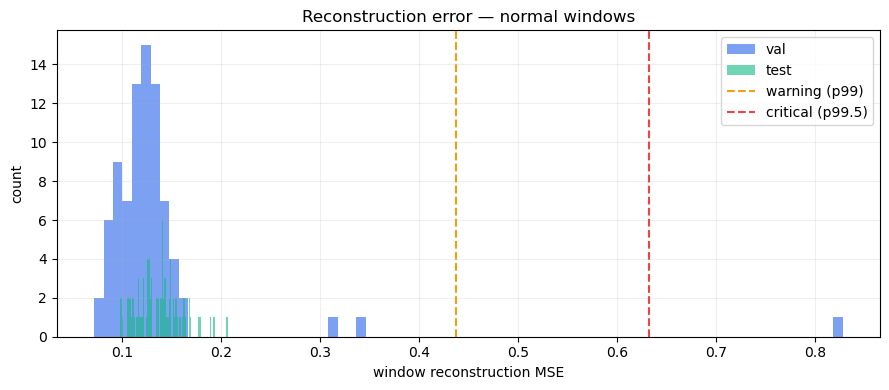

In [6]:
def window_scores(model, Xz):
    model.eval()
    scores = []
    with torch.no_grad():
        for (xb,) in to_dl(Xz, batch_size=256):
            xb = xb.to(DEVICE)
            err = (model(xb) - xb) ** 2
            scores.append(err.mean(dim=(1, 2)).cpu().numpy())
    return np.concatenate(scores)

val_scores  = window_scores(model, Xz_val)
test_scores = window_scores(model, Xz_test)

THRESHOLD_WARNING  = float(np.percentile(val_scores, 99.0))
THRESHOLD_CRITICAL = float(np.percentile(val_scores, 99.5))
print(f'threshold_warning  (p99.0 val) = {THRESHOLD_WARNING:.5f}')
print(f'threshold_critical (p99.5 val) = {THRESHOLD_CRITICAL:.5f}')

sweep = {}
for p in (95.0, 97.0, 99.0, 99.5, 99.9):
    thr = float(np.percentile(val_scores, p))
    sweep[f'p{p}'] = {
        'threshold': thr,
        'test_flag_rate': float((test_scores > thr).mean()),
    }
print(json.dumps(sweep, indent=2))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(val_scores, bins=80, alpha=0.6, label='val', color='#2563EB')
ax.hist(test_scores, bins=80, alpha=0.6, label='test', color='#10B981')
ax.axvline(THRESHOLD_WARNING, color='#F59E0B', ls='--', label='warning (p99)')
ax.axvline(THRESHOLD_CRITICAL, color='#EF4444', ls='--', label='critical (p99.5)')
ax.set_xlabel('window reconstruction MSE'); ax.set_ylabel('count')
ax.set_title('Reconstruction error — normal windows'); ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()


## 7. Sanity check — synthetic perturbations must score higher

In [7]:
# Apply documented perturbations to held-out test windows (z-space) and
# verify the score separates them from normals. The full ROC/PR study
# lives in the eval section; this is the smoke test that the model
# learned *something* before we ship the artifact.
rng = np.random.default_rng(SEED)
idx = rng.choice(len(Xz_test), size=min(200, len(Xz_test)), replace=False)
base = Xz_test[idx].copy()

perturbed = {}
speed_up = base.copy(); speed_up[:, :, 0] *= 3.0; speed_up[:, :, 1] *= 3.0
perturbed['speed_x3'] = speed_up
reverse = base.copy(); reverse[:, :, 2] = -reverse[:, :, 2]
perturbed['direction_reversal'] = reverse
fall = base.copy(); fall[:, 12:, 3] = -fall[:, 12:, 3]; fall[:, 12:, 4] += 3.0
perturbed['aspect_flip_drop'] = fall

normal_scores = window_scores(model, base)
print(f'normal median score: {np.median(normal_scores):.5f}')
sanity = {}
for name, Xp in perturbed.items():
    s = window_scores(model, Xp.astype(np.float32))
    frac = float((s > THRESHOLD_WARNING).mean())
    sanity[name] = {'median_score': float(np.median(s)), 'flagged_frac': frac}
    print(f'{name:<22} median={np.median(s):.5f}  flagged@warning={frac:.1%}')


normal median score: 0.13824
speed_x3               median=0.17706  flagged@warning=0.0%
direction_reversal     median=0.17782  flagged@warning=0.0%
aspect_flip_drop       median=0.79381  flagged@warning=100.0%


## 8. Save artifacts

In [8]:
torch.save({
    'model_state': model.state_dict(),
    'architecture': 'TrajectoryGRUAE',
    'config': {
        'n_features': N_FEATURES,
        'feature_names': FEATURE_NAMES,
        'window': WINDOW,
        'stride': STRIDE,
        'hidden': 32,
        'latent': 16,
        'mu': mu.tolist(),
        'sigma': sigma.tolist(),
        'threshold_warning': THRESHOLD_WARNING,
        'threshold_critical': THRESHOLD_CRITICAL,
        'threshold_provenance': 'p99 / p99.5 of validation normal windows',
        'extraction_detectors': extractors,
    },
}, ARTIFACTS / 'model.pt')

pd.DataFrame(history).to_csv(ARTIFACTS / 'history.csv', index=False)
(ARTIFACTS / 'metrics.json').write_text(json.dumps({
    'n_windows': {'train': len(X_train), 'val': len(X_val), 'test': len(X_test)},
    'best_val_mse': best_val,
    'thresholds': {'warning': THRESHOLD_WARNING, 'critical': THRESHOLD_CRITICAL},
    'threshold_sweep': sweep,
    'perturbation_sanity': sanity,
    'dataset': 'TalTech warehouse clips — YOLO+ByteTrack trajectories (see data/processed/trajectories/manifest.json)',
}, indent=2) + '\n')
print('Saved:', ARTIFACTS / 'model.pt')


Saved: /Users/ayalemzouri/Desktop/Academics/SBDIA2/S4/ML_industrie/Mr.Hajji/labs/Projet_inteligent_warehouse/logivision/ml/artifacts/trajectory_ae/model.pt


## 9. Deployment

`services/stream_processor/anomaly_scorer.py` loads this artifact at CEP
startup (env `ANOMALY_MODE=ae`, the default). Each confirmed ByteTrack
track is scored once per second over its trailing 25-step window using
the *same* `trajectory_features` module; windows above the thresholds
emit `trajectory_anomaly` events (warning/critical) with the dominant
feature attribution in the payload. The legacy stationary/falling rules
still run but are demoted to `severity=info` + `source=rule-baseline` —
they feed the article's comparison table, not the operator's alert feed.
